# Traffic Collision Data Analysis

# Objective

In this case study, you will be working on California Traffic Collision Data Analysis using Apache Spark, a powerful distributed computing framework designed for big data processing. This assignment aims to provide hands-on experience in analyzing large-scale traffic collision datasets using PySpark and AWS services. You will apply data analytics techniques to clean, transform, and explore crash data, drawing meaningful insights to support traffic safety and urban planning. Beyond understanding how big data tools optimize performance on a single machine and across clusters, you will develop a structured approach to analyzing crash trends, identifying high-risk locations, and evaluating contributing factors to traffic incidents. Additionally, you will utilize AWS S3 to store the processed data efficiently after the ETL process, enabling scalable storage and easy retrieval for further analysis.


# Business Value:

Traffic collisions pose significant risks to public safety, requiring continuous monitoring and analysis to enhance road safety measures. Government agencies, city planners, and policymakers must leverage data-driven insights to improve infrastructure, optimize traffic management, and implement preventive measures.

In this assignment, you will analyze California traffic collision data to uncover patterns related to accident severity, location-based risks, and key contributing factors. With Apache Spark's ability to handle large datasets efficiently and AWS S3's scalable storage, transportation authorities can process vast amounts of crash data in real time, enabling faster and more informed decision-making.

As an analyst examining traffic safety trends, your task is to analyze historical crash data to derive actionable insights that can drive policy improvements and safety interventions. Your analysis will help identify high-risk areas, categorize accidents by severity and contributing factors, and store the processed data in an AWS S3 bucket for scalable and long-term storage.

By leveraging big data analytics and cloud-based storage, urban planners and traffic authorities can enhance road safety strategies, reduce accident rates, and improve public transportation planning.


# Dataset Overview

The dataset used in this analysis consists of California traffic collision data obtained from the Statewide Integrated Traffic Records System (SWITRS). It includes detailed records of traffic incidents across California, covering various attributes such as location, severity, involved parties, and contributing factors. The dataset has been preprocessed and transformed using PySpark to facilitate large-scale analysis. By leveraging Apache Spark, we ensure efficient data handling, enabling deeper insights into traffic patterns, accident trends, and potential safety improvements.

The dataset is a .sqlite file contains detailed information about traffic collisions across California and is structured into four primary tables:
- `collisions` table contains information about the collision, where it happened, what vehicles were involved.

- `parties` table contains information about the groups people involved in the collision including age, sex, and sobriety.

- `victims` table contains information about the injuries of specific people involved in the collision.

- `locations` table contains information about the geographical location and details of road intersections.

# Assignment Tasks

<ol>
    <li>
        <strong>Data Preparation</strong></br>
        The dataset consists of structured tables containing traffic collision data. Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.</br>
        Check for data consistency and ensure all columns are correctly formatted.</br>
        Apply sampling techniques if needed to extract a representative subset for analysis.</br>
        Structure and prepare the data for further processing and analysis.</br>
    </br>
    <li>
        <strong>Data Cleaning</strong></br>
            2.1 <strong>Fixing Columns:</strong> Ensure all columns are properly named and formatted.</br>
            2.2 <strong>Handling Missing Values:</strong> Decide on an approach to handle missing data (e.g., imputation or removal). Mention the approach in your report.</br>
            2.3 <strong>Handling Outliers:</strong> Identify outliers in the dataset and explain why they are considered outliers. It is not necessary to remove them for this task, but mention your approach for handling them.</br>
    </br>
    <li>
        <strong>Exploratory Data Analysis</strong></br>
        Finding Patterns and analyze the dataset and find patterns based on the following points:
                <ul>
                3.1 Classify variables into categorical and numerical types.</br>
                3.2 Analyze the distribution of collision severity.</br>
                3.3 Examine weather conditions during collisions.</br>
                3.4 Analyze the distribution of victim ages.</br>
                3.5 Study the relationship between collision severity and the number of victims.</br>
                3.6 Analyze the correlation between weather conditions and collision severity.</br>
                3.7 Visualize the impact of lighting conditions on collision severity.</br>
                3.8 Extract and analyze weekday-wise collision trends.</br>
                3.9 Assess the number of collisions occurring on different days of the week.</br>
                3.10 Study spatial distribution of collisions by county.</br>
                3.11 Generate a scatter plot to analyze collision locations geographically.</br>
                3.12 Extract and analyze collision trends over time, including yearly, monthly, and hourly trends.</br>
</ul>
</br>
<li>
<strong>ETL Querying</strong><br>
Write PySpark SQL queries for the following:</br>
<ol>
    4.1. Identify the top 5 counties with the highest number of collisions.</br>
    4.2. Identify the month with the highest number of collisions.</br>
    4.3. Determine the most common weather condition during collisions.</br>
    4.4. Calculate the percentage of collisions that resulted in fatalities.</br>
    4.5. Find the most dangerous time of day for collisions.</br>
    4.6. Identify the top 5 road surface conditions with the highest collision frequency.</br>
    4.7. Analyze lighting conditions that contribute to the highest number of collisions.</br>
</ol>
</br>
<li>
<strong>Conclusion</strong></br>
Provide final insights and recommendations based on the analysis:
    <ul>
        5.1 Recommendations to improve road safety by identifying high-risk locations and peak accident times for infrastructure improvements.</br>
        5.2 Suggestions to optimize traffic management by analyzing trends in collision severity, weather conditions, and lighting to improve road design and traffic signal timing.</br>
        5.3 Propose data-driven policy changes to enhance pedestrian and cyclist safety based on collision trends involving vulnerable road users.</br>
        5.4 Identify potential high-risk zones for proactive intervention by examining geographic collision density and historical accident data.</br>
        5.5 Assess the impact of environmental factors such as weather, road surface conditions, and lighting on accident frequency and severity.</br>
        5.6 Develop predictive models to anticipate collision hotspots and support proactive safety measures.</br>
        </ul>
        Conclude the analysis by summarizing key findings and business implications.</br>
        Explain the results of univariate, segmented univariate, and bivariate analyses in real-world traffic safety and policy terms.</br>
        Include visualizations and summarize the most important results in the report. Insights should explain why each variable is important and how they can influence traffic safety policies and urban planning.</br>
        </ul>
        </br>
    <li>
    <strong>Visualization Integration [Optional]</strong>
    <p>Enhance the project by incorporating a visualization component that connects the processed data stored in an S3 bucket to a business intelligence tool such as Tableau or Power BI. This involves setting up the connection between the S3 bucket and the chosen visualization tool, importing the processed dataset for analysis and visualization, creating interactive dashboards to explore key trends and insights and ensuring data updates are reflected dynamically in the visualization tool.<br>
</br>
</ol>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Install Required Libraries

In [3]:
## Install the required libraries
!pip install --quiet pyspark==3.5.4 pandas==2.2.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 14.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.4 which is incompatible.


In [4]:
# Import the necessary libraries
import sqlite3
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, to_date,count,when,isnan,isnull,to_timestamp,dayofweek
from pyspark.ml.feature import StringIndexer

#**1. Data Preparation** <font color = red>[5 marks]</font> <br>

The dataset consists of structured tables containing traffic collision data.

Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.

Check for data consistency and ensure all columns are correctly formatted.

In [5]:
# spark initialization
spark = SparkSession.builder.appName("Traffic collision analysis").getOrCreate()

In [6]:
# Write code to load the data and check the schema
# Collision df
cdf = spark.read.option("header","True").csv("/content/drive/MyDrive/Assignments/traffic_data/sample_collisions.csv")
cdf.printSchema()

root
 |-- case_id: string (nullable = true)
 |-- jurisdiction: string (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: string (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: string (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: string (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: string (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: string (nullable = true)
 |-- caltrans_county: string (nullable = true)
 |-- caltrans_district: string (nullable = true)
 |-- st

In [8]:
# victims
victim_df=spark.read.option("header","True").csv("/content/drive/MyDrive/Assignments/traffic_data/sample_victims.csv")
victim_df.printSchema()

root
 |-- id: string (nullable = true)
 |-- case_id: string (nullable = true)
 |-- party_number: string (nullable = true)
 |-- victim_role: string (nullable = true)
 |-- victim_sex: string (nullable = true)
 |-- victim_age: string (nullable = true)
 |-- victim_degree_of_injury: string (nullable = true)
 |-- victim_seating_position: string (nullable = true)
 |-- victim_safety_equipment_1: string (nullable = true)
 |-- victim_safety_equipment_2: string (nullable = true)
 |-- victim_ejected: string (nullable = true)



#**2. Data Cleaning** <font color = red>[20 marks]</font> <br>


In [10]:
#Display Schema & Sample Data
cdf.printSchema()
cdf.show(5)

root
 |-- case_id: string (nullable = true)
 |-- jurisdiction: string (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: string (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: string (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: string (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: string (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: string (nullable = true)
 |-- caltrans_county: string (nullable = true)
 |-- caltrans_district: string (nullable = true)
 |-- st

In [11]:
# victim data
victim_df.show(5)

+-------+----------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|     id|   case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+-------+----------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|2166324| 6324923.0|           1|     driver|      male|      62.0|      complaint of pain|                 driver|     air bag not deployed|     lap/shoulder harn...|   not ejected|
| 779470|  761473.0|           1|  passenger|      male|      25.0|              no injury|       passenger seat 3|     lap/shoulder harn...|                     NULL|   not ejected|
| 742636|  723123.0|           1|     driver|      NULL|      31.0|      complaint of

##**2.1 Missing Values** <font color = red>[10 marks]</font> <br>


In [12]:
#Check for Missing Values for collision df
cdf.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c) for c in cdf.columns
    ]).show()


+-------+------------+----------+------------------+---------+----------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+-----------+-----------------+---------------------------+-----------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-----------

In [13]:
# Check for Missing Values for victim df
victim_df.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c) for c in victim_df.columns
    ]).show()

+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
| id|case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|  0|      0|           0|          1|     24041|     32145|                      0|                   1913|                    55215|                   310220|          4272|
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+



In [14]:
#Drop Sparse Columns
total_count=cdf.count()
missing_row_counts=cdf.select([
    (count(when(col(c).isNull() | isnan(c),c))/total_count).alias(c) for c in cdf.columns
])
missing_row_counts.show()

+-------+--------------------+--------------------+------------------+---------+--------------------+--------------------+---------------+-------------------+---------+-------------+--------------------+------------------+--------------------+--------------------+--------+------------------+------------------+--------------------+-----------------------+------------------+------------------+------------------+------------------+------------------+-----------------+--------------------+------------------+--------------------+--------------------+-----------+------------------------+----------------------+-------------------+------------------------+-----------+-------------------+---------------------------+--------------------+--------------------+-------------------+--------------------+--------------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-----------

In [15]:
# Drop sparse columns
total_victim_count=victim_df.count()
missing_row_victim_counts=victim_df.select([
    (count(when(col(c).isNull() | isnan(c),c))/total_count).alias(c) for c in victim_df.columns
])
missing_row_victim_counts.show()

# Not required there is no such column having very large missing values

+---+-------+------------+--------------------+--------------------+--------------------+-----------------------+-----------------------+-------------------------+-------------------------+--------------------+
| id|case_id|party_number|         victim_role|          victim_sex|          victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|      victim_ejected|
+---+-------+------------+--------------------+--------------------+--------------------+-----------------------+-----------------------+-------------------------+-------------------------+--------------------+
|0.0|    0.0|         0.0|1.068614679987304...|0.025690565521574796|0.034350618888191915|                    0.0|   0.002044259882815...|      0.05900355955549904|      0.33150564602566174|0.004565121912905767|
+---+-------+------------+--------------------+--------------------+--------------------+-----------------------+-----------------------+-------------------

In [16]:
# removing the columns having missing values more than 50 % from collision data
total_counts=cdf.count()
columns_to_drop=[]
for c in cdf.columns:
  missing_row_ratio= cdf.filter(col(c).isNull() | isnan(c)).count()/total_counts
  if missing_row_ratio>=0.5:
    columns_to_drop.append(c)
print(columns_to_drop)

['reporting_district', 'caltrans_county', 'caltrans_district', 'state_route', 'postmile', 'location_type', 'side_of_highway', 'pcf_violation_subsection', 'latitude', 'longitude']


In [17]:
cleaned_df=cdf.drop(*columns_to_drop)
cleaned_df.show(5)

+----------+------------+----------+--------------+----------------+--------------------+---------------+-----------------+-------------------+----------------+--------------+-----------+------------------+--------------+--------+---------+------------+---------+-----------------------+--------+--------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+---------------+-----------------+---------------------------+--------------------+------------+----------------+--------------------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-------------------------+--------------------------+--------------+--------------+---

In [18]:
#Convert Data Types
def fix_data_types(df,numeric_cols=None,float_cols=None,date_cols=None,time_cols=None):
  for col_name in float_cols:
    df=df.withColumn(col_name,col(col_name).cast("float"))
  for c in date_cols:
    df=df.withColumn(c,to_date(col(c),"yyyy-MM-dd"))
  for c in numeric_cols:
    df=df.withColumn(c,col(c).cast("long"))
  for c in time_cols:
    df=df.withColumn(c,to_timestamp(c,"HH:mm:ss"))
  return df


In [19]:
# Fixing data types for collision data set
formated_df=fix_data_types(
    numeric_cols={"jurisdiction","county_city_location",
                  "intersection",
                  "state_highway_indicator",
                  "killed_victims",
                  "injured_victims",
                  "party_count",
                  "chp_road_type",
                  "pedestrian_collision",
                  "bicycle_collision",
                  "motorcycle_collision",
                  "truck_collision",
                  "not_private_property",
                  "severe_injury_count",
                  "other_visible_injury_count",
                  "complaint_of_pain_injury_count",
                  "pedestrian_killed_count",
                  "pedestrian_injured_count",
                  "bicyclist_killed_count",
                  "bicyclist_injured_count",
                  "motorcyclist_killed_count",
                  "motorcyclist_injured_count","special_condition","tow_away","pcf_violation"},
    float_cols={"distance"},
    date_cols={"collision_date","process_date"},
    time_cols={"collision_time"},
    df=cleaned_df
    )
formated_df.printSchema()
formated_df.show(5)

root
 |-- case_id: string (nullable = true)
 |-- jurisdiction: long (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: long (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: long (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: float (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: long (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: long (nullable = true)
 |-- tow_away: long (nullable = true)
 |-- collision_severity: string (nullable = true)
 |-- killed_victims: long (nullable = true)
 |-- injured_victims: long (null

In [20]:
# Fixing data types for victim data sets
formated_victim_df=fix_data_types(float_cols=[],date_cols=[],time_cols=[],numeric_cols=["victim_age","party_number"],df=victim_df)
formated_victim_df.printSchema()
formated_victim_df.show(5)

root
 |-- id: string (nullable = true)
 |-- case_id: string (nullable = true)
 |-- party_number: long (nullable = true)
 |-- victim_role: string (nullable = true)
 |-- victim_sex: string (nullable = true)
 |-- victim_age: long (nullable = true)
 |-- victim_degree_of_injury: string (nullable = true)
 |-- victim_seating_position: string (nullable = true)
 |-- victim_safety_equipment_1: string (nullable = true)
 |-- victim_safety_equipment_2: string (nullable = true)
 |-- victim_ejected: string (nullable = true)

+-------+----------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|     id|   case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+-------+----------+------------+-----------+----------+----------+-----------------------+-----------------------+---

In [21]:
#Handle Missing Values
formated_df.select([
    count(when(col(c).isNull(),c)).alias(c) for c in formated_df.columns
]).show()

formated_df.count()


+-------+------------+----------+---------+----------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+--------+------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+-----------+-----------------+---------------------------+-----------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-------------------------+--------------------------+--------------+--------------+------------+
|case_id|jurisdiction|officer_id|chp_shift|

935791

In [22]:
# handle missing values for victim df
formated_victim_df.select([
    count(when(col(c).isNull(),c)).alias(c) for c in formated_victim_df.columns
]).show()

formated_victim_df.count()

+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
| id|case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|  0|      0|           0|          1|     24041|     32145|                      0|                   1913|                    55215|                   310220|          4272|
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+



963933

In [23]:
# drop rows having less missing values
formated_df=formated_df.na.drop(subset=["jurisdiction","officer_id","population","chp_beat_class","primary_road","secondary_road","state_highway_indicator","pedestrian_action","killed_victims","injured_victims"])

In [24]:
# drop rows having less missing values for victim df
formated_victim_df=formated_victim_df.na.drop(subset=["victim_role","victim_seating_position","victim_ejected"])

In [25]:
# victim_sex victim df
formated_victim_df.groupBy("victim_sex").count().show()

+----------+------+
|victim_sex| count|
+----------+------+
|         3|     5|
|      NULL| 23742|
|    female|469385|
|         X|     4|
|      male|465815|
|         1|     2|
|         4|    12|
+----------+------+



In [26]:
# remove the values other than male and female in victim DF
formated_victim_df=formated_victim_df.filter(col("victim_sex").isin(["male","female"]))

In [27]:
# victim_age victim df
formated_victim_df.groupBy("victim_age").count().show(5)

+----------+-----+
|victim_age|count|
+----------+-----+
|        29|15458|
|        26|18418|
|        65| 4759|
|        19|29541|
|        54| 8929|
+----------+-----+
only showing top 5 rows



In [28]:
# victim_age in victim df to be replace with the median value and removing the age where 0
median_age=formated_victim_df.approxQuantile("victim_age",[0.5],0.0)[0]
formated_victim_df=formated_victim_df.filter(col("victim_age")!=0)
formated_victim_df=formated_victim_df.na.fill(value=median_age, subset=["victim_age"])

In [29]:
# victim_safety_equipment_1 from victim df
formated_victim_df.groupBy("victim_safety_equipment_1").count().show()

+-------------------------+------+
|victim_safety_equipment_1| count|
+-------------------------+------+
|     passenger, motorc...|   126|
|         air bag deployed|138610|
|             not required|141674|
|     lap/shoulder harn...|175122|
|                  unknown|  9441|
|                     NULL| 45474|
|     shoulder harness ...|   718|
|     no child restrain...|   625|
|     child restraint i...|   187|
|     lap/shoulder harn...|  4819|
|     passive restraint...|   498|
|     passive restraint...|   129|
|                    other|  6879|
|     driver, motorcycl...|  4020|
|            lap belt used|  8171|
|     air bag not deployed|340180|
|        lap belt not used|  1284|
|     shoulder harness ...|  1445|
|     passenger, motorc...|  1098|
|                        1|     3|
+-------------------------+------+
only showing top 20 rows



In [30]:
# victim_safety_equipment_1 in victim df to replace the null values with unknown
formated_victim_df=formated_victim_df.na.fill(value="unknown",subset=["victim_safety_equipment_1"])

In [31]:
# victim_safety_equipment_2 in victim df
formated_victim_df.groupBy("victim_safety_equipment_2").count().show()

+-------------------------+------+
|victim_safety_equipment_2| count|
+-------------------------+------+
|     passenger, motorc...|   258|
|         air bag deployed|  2917|
|             not required|  4715|
|     lap/shoulder harn...|505404|
|                  unknown|  8564|
|                     NULL|283990|
|     no child restrain...|  1204|
|     shoulder harness ...|  1212|
|     child restraint i...|   385|
|     lap/shoulder harn...| 10786|
|     passive restraint...|   625|
|     passive restraint...|   134|
|                    other|   303|
|     driver, motorcycl...|  7516|
|                        Z|     4|
|            lap belt used|  9235|
|     air bag not deployed|  3388|
|        lap belt not used|  1225|
|     shoulder harness ...|  2325|
|     passenger, motorc...|  1074|
+-------------------------+------+
only showing top 20 rows



In [32]:
# victim_safety_equipment_2 in victim df to replace the null values with unknown
formated_victim_df=formated_victim_df.na.fill(value="unknown",subset=["victim_safety_equipment_2"])

In [33]:
# pecial_condition collision df
formated_df.groupBy("special_condition").count().show()

+-----------------+------+
|special_condition| count|
+-----------------+------+
|                0|875656|
|             NULL| 51566|
|                1|  3400|
+-----------------+------+



In [34]:
formated_df=formated_df.na.fill(value=0,subset=["special_condition"])

In [35]:
# beat_number collision DF
formated_df=formated_df.na.drop(subset=["beat_number"])

In [36]:
# direction
formated_df.groupBy("direction").count().show()

+---------+------+
|direction| count|
+---------+------+
|     NULL|198905|
|     west|147248|
|    north|178519|
|     east|147973|
|    south|178919|
+---------+------+



In [37]:
# lot of data are missing here so replacing null with unknown
formated_df=formated_df.na.fill(value='unknown',subset=["direction"])

In [38]:
# intersection
formated_df.groupBy("intersection").count().show()

+------------+------+
|intersection| count|
+------------+------+
|           0|658966|
|        NULL|  7859|
|           1|184739|
+------------+------+



In [39]:
# filling 0 as most of the values are 0
formated_df=formated_df.na.fill(value=0,subset=["intersection"])

In [40]:
# weather_1
formated_df.groupBy("weather_1").count().show()

+---------+------+
|weather_1| count|
+---------+------+
|      fog|  3562|
|  raining| 29113|
|     NULL|  3932|
|    other|   976|
|    clear|699280|
|   cloudy|113073|
|     wind|   340|
|  snowing|  1288|
+---------+------+



In [41]:
# filling 'other' to weather
formated_df=formated_df.na.fill(value='other',subset=["weather_1"])

In [42]:
# tow_away
formated_df.groupBy("tow_away").count().show()

+--------+------+
|tow_away| count|
+--------+------+
|       0|417822|
|    NULL|  4682|
|       1|429060|
+--------+------+



In [43]:
# removing null values
formated_df=formated_df.na.drop(subset=["tow_away"])

In [44]:
# primary_collision_factor
formated_df.groupBy("primary_collision_factor").count().show()

+------------------------+------+
|primary_collision_factor| count|
+------------------------+------+
|    vehicle code viol...|796383|
|                 unknown| 21265|
|                    NULL|  3953|
|             fell asleep|   761|
|       other than driver| 19144|
|    other improper dr...|  5376|
+------------------------+------+



In [45]:
# filling unknown
formated_df=formated_df.na.fill(value='unknown',subset=["primary_collision_factor"])

In [46]:
# pcf_violation_category
formated_df.groupBy("pcf_violation_category").count().show()

+----------------------+------+
|pcf_violation_category| count|
+----------------------+------+
|                brakes|   220|
|                   dui| 62027|
|               unknown| 24363|
|                  NULL| 12404|
|  following too clo...| 18272|
|    unsafe lane change| 62379|
|  other hazardous v...|  8649|
|  unsafe starting o...| 31096|
|           fell asleep|   761|
|        pedestrian dui|    26|
|  automobile right ...| 95708|
|                lights|    95|
|  traffic signals a...| 43249|
|    wrong side of road| 19306|
|  pedestrian violation|  7647|
|      improper passing|  7769|
|       other equipment|  1115|
|              speeding|269745|
|  other than driver...| 19144|
|  pedestrian right ...|  7893|
+----------------------+------+
only showing top 20 rows



In [47]:
# fill unknown
formated_df=formated_df.na.fill(value='unknown',subset=["pcf_violation_category"])

In [48]:
# type_of_collision
formated_df.groupBy("type_of_collision").count().show()

+-----------------+------+
|type_of_collision| count|
+-----------------+------+
|        sideswipe|152126|
|       pedestrian| 20177|
|             NULL|  6584|
|         rear end|287370|
|          head-on| 35451|
|            other| 22199|
|       hit object|141556|
|        broadside|157866|
|       overturned| 23553|
+-----------------+------+



In [49]:
# replace other
formated_df=formated_df.na.fill(value="other",subset=["type_of_collision"])

In [50]:
# pcf_violation
formated_df.select("pcf_violation").distinct().count()

450

In [51]:
# there are 450 different violation type and replacing null value as 0 to classify the unknown pcfviolation type
formated_df=formated_df.na.fill(value=0,subset=["pcf_violation"])

In [52]:
# motor_vehicle_involved_with
formated_df.groupBy("motor_vehicle_involved_with").count().show()

+---------------------------+------+
|motor_vehicle_involved_with| count|
+---------------------------+------+
|                 pedestrian| 21816|
|                          8|    18|
|       parked motor vehicle| 60203|
|                          0|     1|
|                       NULL|  4110|
|        other motor vehicle|554836|
|               fixed object|134972|
|                     animal|  3926|
|                      train|   215|
|       motor vehicle on ...|  5324|
|               other object| 18354|
|                          2|    10|
|              non-collision| 24128|
|                    bicycle| 18967|
|                          3|     1|
|                          9|     1|
+---------------------------+------+



In [53]:
# replacing null values with other object
formated_df=formated_df.na.fill(value="other object", subset=["motor_vehicle_involved_with"])

In [54]:
# road_surface
formated_df.groupBy("road_surface").count().show()

+------------+------+
|road_surface| count|
+------------+------+
|         wet| 70210|
|       snowy|  3928|
|        NULL|  6936|
|         dry|764834|
|    slippery|   967|
|           H|     7|
+------------+------+



In [55]:
# Adding an unknown category unknknown
formated_df=formated_df.na.fill(value='unknown',subset=["road_surface"])

In [56]:
# road_condition_1
formated_df.groupBy("road_condition_1").count().show()

+----------------+------+
|road_condition_1| count|
+----------------+------+
|         flooded|   676|
|  loose material|  1690|
|            NULL|  6732|
|          normal|813608|
|           other|  3079|
|     obstruction|  3452|
|           holes|  2436|
|    construction| 14290|
|   reduced width|   919|
+----------------+------+



In [57]:
# merge the null category with other
formated_df=formated_df.na.fill(value='other',subset=["road_condition_1"])

In [58]:
# lighting
formated_df.groupBy("lighting").count().show()

+--------------------+------+
|            lighting| count|
+--------------------+------+
|dark with no stre...| 72559|
|dark with street ...|173783|
|                NULL|  4514|
|            daylight|564733|
|dark with street ...|  1622|
|        dusk or dawn| 29671|
+--------------------+------+



In [59]:
# adding unknown category
formated_df=formated_df.na.fill(value='unknown',subset=["lighting"])

In [60]:
# control_device
formated_df.groupBy("control_device").count().show()

+---------------+------+
| control_device| count|
+---------------+------+
|not functioning|  2318|
|           none|575165|
|           NULL|  4815|
|       obscured|   552|
|    functioning|264031|
|              H|     1|
+---------------+------+



In [61]:
# as most of the values are none so replacing the null categories with none
formated_df=formated_df.na.fill(value='none',subset=["control_device"])

In [62]:
# statewide_vehicle_type_at_fault
formated_df.groupBy("statewide_vehicle_type_at_fault").count().show()

+-------------------------------+------+
|statewide_vehicle_type_at_fault| count|
+-------------------------------+------+
|                          moped|    91|
|                      schoolbus|  1500|
|                  passenger car|511481|
|                     pedestrian|  7456|
|           truck or truck tr...| 13587|
|           passenger car wit...|  1198|
|           pickup or panel t...|  3970|
|                           NULL|164075|
|                      other bus|  2604|
|              emergency vehicle|  4167|
|           motorcycle or sco...| 14086|
|                  other vehicle|  3092|
|           highway construct...|   180|
|           pickup or panel t...| 97152|
|           truck or truck tr...| 10235|
|                        bicycle| 12008|
+-------------------------------+------+



In [63]:
# merging null category to other vehicle
formated_df=formated_df.na.fill(value='other vehicle',subset=["statewide_vehicle_type_at_fault"])

In [64]:
# chp_vehicle_type_at_fault
formated_df.groupBy("chp_vehicle_type_at_fault").count().show()

+-------------------------+------+
|chp_vehicle_type_at_fault| count|
+-------------------------+------+
|     two-axle tank tru...|     9|
|     federally legal semi|     3|
|               motorcycle| 12175|
|     pickups and panel...|   221|
|     school bus contra...|   259|
|                fork lift|    39|
|     hwy. construction...|   139|
|     school bus contra...|   107|
|     three axle tank t...|   232|
|                     semi|    44|
|               pedestrian|  5992|
|     implement of husb...|   145|
|     farm labor vehicl...|    18|
|     truck tractor: ha...|    23|
|     three or more axl...|  3180|
|              paratransit|   268|
|                ambulance|   228|
|     school bus privat...|    55|
|                     NULL|209278|
|       two-axle tow truck|   716|
+-------------------------+------+
only showing top 20 rows



In [65]:
# fill with unknown
formated_df=formated_df.na.fill(value='unknown',subset=["chp_vehicle_type_at_fault"])

In [66]:
# collision_time: as there are very less values for the colision time, we can drop the missing rows it
formated_df=formated_df.na.drop(subset=["collision_time"])

In [67]:
# the final cleaned collision data frame with handled missing values
formated_df.select([
    count(when(col(c).isNull(),c)).alias(c) for c in formated_df.columns
]).show()

formated_df.count()


+-------+------------+----------+---------+----------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+--------+------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+-----------+-----------------+---------------------------+-----------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-------------------------+--------------------------+--------------+--------------+------------+
|case_id|jurisdiction|officer_id|chp_shift|

839532

In [68]:
# The final cleaned victim data frame with handled missing values
formated_victim_df.select([
    count(when(col(c).isNull(),c)).alias(c) for c in formated_victim_df.columns
]).show()

formated_victim_df.count()

+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
| id|case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|  0|      0|           0|          0|         0|         0|                      0|                      0|                        0|                        0|             0|
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+



905470

##**2.2 Fixing Columns** <font color = red>[5 marks]</font> <br>


In [69]:
#Remove Duplicates
formated_df=formated_df.dropDuplicates()
formated_df.count()

839532

In [70]:
# remove duplicates in victim df
formated_victim_df=formated_victim_df.dropDuplicates()
formated_victim_df.count()

905470

In [71]:
#Detect Outliers using IQR
# List of numerical columns to check for outliers
numerical_columns=["distance","injured_victims","party_count","severe_injury_count","other_visible_injury_count","complaint_of_pain_injury_count","pedestrian_killed_count","bicyclist_killed_count","motorcyclist_killed_count","motorcyclist_injured_count"]
formated_df.select(numerical_columns).summary().show()

+-------+------------------+------------------+------------------+-------------------+--------------------------+------------------------------+-----------------------+----------------------+-------------------------+--------------------------+
|summary|          distance|   injured_victims|       party_count|severe_injury_count|other_visible_injury_count|complaint_of_pain_injury_count|pedestrian_killed_count|bicyclist_killed_count|motorcyclist_killed_count|motorcyclist_injured_count|
+-------+------------------+------------------+------------------+-------------------+--------------------------+------------------------------+-----------------------+----------------------+-------------------------+--------------------------+
|  count|            839532|            839532|            839532|             839532|                    839532|                        839532|                 839532|                839532|                   839532|                    839532|
|   mean| 729.274171

In [72]:
# Detect Outliers using IQR in victim df
# List of numerical columns to check for outliers
formated_victim_df.select("victim_age").summary().show()

+-------+------------------+
|summary|        victim_age|
+-------+------------------+
|  count|            905470|
|   mean| 31.28242349277171|
| stddev|19.716550268273668|
|    min|                 1|
|    25%|                17|
|    50%|                27|
|    75%|                45|
|    max|               999|
+-------+------------------+



##**2.3 Outlier Analysis** <font color = red>[5 marks]</font> <br>


In [73]:
# features like "inured_victims", "party_count", "severe_injury_count","other_visible_injury_count","complaint_of_pain_injury_count","pedestrian_killed_count","bicyclist_killed_count","motorcyclist_killed_count","motorcyclist_injured_count" ---
# the extreme values can be possible

# from the list of numeric features distance and pcf_violation are two such feature that is visibly having very extreme values and has to be handled

# distance feature
# for distance - there is no negetive values, so need to remove the outliers in positive extremes
q1,q3=formated_df.approxQuantile("distance",[0.25,0.75],0.0)
iqr=q3-q1
upper_bound=q3+1.5*iqr

formated_df=formated_df.filter(col("distance")<=upper_bound)
formated_df.count()

736734

In [74]:
# for victim df the only numerical column is victim_age
q1,q3=formated_victim_df.approxQuantile("victim_age",[0.25,0.75],0.0)
iqr=q3-q1
upper_bound=q3+1.5*iqr

formated_victim_df=formated_victim_df.filter(col("victim_age")<=upper_bound)
formated_victim_df.count()

902644

#**3. Exploratory Data Analysis** <font color = red>[65 marks]</font> <br>


##**3.1.1. Data Preparation** <font color = red>[5 marks]</font> <br>

Q: Classify variables into categorical and numerical.

In [75]:
# Collision df
formated_df.show(5)

+--------------------+------------+----------+--------------+---------------+--------------------+---------------+-----------------+-------------------+----------------+--------------+-----------+----------------+--------------+--------+---------+------------+---------+-----------------------+--------+--------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+---------------+-----------------+---------------------------+--------------------+------------+----------------+--------------------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-------------------------+--------------------------+--------------+-----------

In [76]:
# Victim DF
formated_victim_df.show(5)

+-------+----------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|     id|   case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+-------+----------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|4436197|90430563.0|           1|     driver|      male|        50|      complaint of pain|                 driver|             not required|     driver, motorcycl...| fully ejected|
|2089326| 6250344.0|           1|  bicyclist|      male|        27|   other visible injury|                 driver|             not required|                  unknown| fully ejected|
| 351062| 4447606.0|           1|  passenger|      male|        13|              no i

In [77]:
# Encode Categorical Variables
categorical_cols=["chp_shift","population","county_location","beat_type","chp_beat_type","chp_beat_class","beat_number","direction","weather_1","collision_severity","primary_collision_factor","pcf_violation_category","hit_and_run","type_of_collision","motor_vehicle_involved_with","pedestrian_action","road_surface","road_condition_1","lighting","control_device","statewide_vehicle_type_at_fault","chp_vehicle_type_at_fault"]

# String Indexing for Categorical Columns, 0.0 being the highest frequency
for c in categorical_cols:
  inedxer = StringIndexer(inputCol=c,outputCol=c+"_indexed")
  formated_df=inedxer.fit(formated_df).transform(formated_df)



In [78]:
# Reordering & Renaming Columns
formated_df.printSchema()

root
 |-- case_id: string (nullable = true)
 |-- jurisdiction: long (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: long (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: long (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: float (nullable = true)
 |-- direction: string (nullable = false)
 |-- intersection: long (nullable = true)
 |-- weather_1: string (nullable = false)
 |-- state_highway_indicator: long (nullable = true)
 |-- tow_away: long (nullable = true)
 |-- collision_severity: string (nullable = true)
 |-- killed_victims: long (nullable = true)
 |-- injured_victims: long (nu

In [79]:
# Collision df
formated_df.columns

['case_id',
 'jurisdiction',
 'officer_id',
 'chp_shift',
 'population',
 'county_city_location',
 'county_location',
 'special_condition',
 'beat_type',
 'chp_beat_type',
 'chp_beat_class',
 'beat_number',
 'primary_road',
 'secondary_road',
 'distance',
 'direction',
 'intersection',
 'weather_1',
 'state_highway_indicator',
 'tow_away',
 'collision_severity',
 'killed_victims',
 'injured_victims',
 'party_count',
 'primary_collision_factor',
 'pcf_violation_category',
 'pcf_violation',
 'hit_and_run',
 'type_of_collision',
 'motor_vehicle_involved_with',
 'pedestrian_action',
 'road_surface',
 'road_condition_1',
 'lighting',
 'control_device',
 'chp_road_type',
 'pedestrian_collision',
 'bicycle_collision',
 'motorcycle_collision',
 'truck_collision',
 'not_private_property',
 'statewide_vehicle_type_at_fault',
 'chp_vehicle_type_at_fault',
 'severe_injury_count',
 'other_visible_injury_count',
 'complaint_of_pain_injury_count',
 'pedestrian_killed_count',
 'pedestrian_injured_coun

In [80]:
# For collision df
formated_df=formated_df.withColumnRenamed("weather_1","weather") \
  .withColumnRenamed("road_condition_1","road_condition") \
  .withColumnRenamed("weather_1_indexed","weather_indexed") \
  .withColumnRenamed("road_condition_1_indexed","road_condition_indexed")

In [81]:
# Final cleaned data
final_cleaned_df=formated_df

final_cleaned_df.show(5)


+--------------------+------------+----------+--------------+----------------+--------------------+---------------+-----------------+-------------------+----------------+--------------+-----------+----------------+---------------+--------+---------+------------+-------+-----------------------+--------+--------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+---------------+-----------------+---------------------------+--------------------+------------+--------------+--------------------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-------------------------+--------------------------+--------------+-------------

In [82]:
# change data type of the new columns to integer
numerical_cols=["chp_shift_indexed","population_indexed","county_location_indexed","beat_type_indexed","chp_beat_type_indexed","chp_beat_class_indexed","beat_number_indexed","direction_indexed","weather_indexed","collision_severity_indexed","primary_collision_factor_indexed","pcf_violation_category_indexed","hit_and_run_indexed","type_of_collision_indexed","motor_vehicle_involved_with_indexed","pedestrian_action_indexed","road_surface_indexed","road_condition_indexed","lighting_indexed","control_device_indexed","statewide_vehicle_type_at_fault_indexed","chp_vehicle_type_at_fault_indexed"]
final_cleaned_df=fix_data_types(float_cols=[],date_cols=[],time_cols=[],numeric_cols=numerical_cols,df=final_cleaned_df)

Loading the Final Cleaned Dataset into S3 Bucket

In [115]:
# writing the cleaned collision data set to output
final_cleaned_df.show(5)
final_cleaned_df.write.option("header","True").mode("overwrite").csv("/content/drive/MyDrive/Assignments/traffic_data/output")

+--------------------+------------+----------+--------------+---------------+--------------------+---------------+-----------------+-------------------+----------------+--------------+-----------+----------------+--------------+--------+---------+------------+-------+-----------------------+--------+--------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+---------------+-----------------+---------------------------+--------------------+------------+--------------+--------------------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-------------------------+--------------------------+--------------+---------------

In [84]:
# writing the cleaned victim data set to output
final_cleaned_victim_df=formated_victim_df
final_cleaned_victim_df.show(5)
final_cleaned_victim_df.write.option("header","True").mode("overwrite").csv("/content/drive/MyDrive/Assignments/traffic_data/output")

+-------+----------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|     id|   case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+-------+----------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|4436197|90430563.0|           1|     driver|      male|        50|      complaint of pain|                 driver|             not required|     driver, motorcycl...| fully ejected|
|2089326| 6250344.0|           1|  bicyclist|      male|        27|   other visible injury|                 driver|             not required|                  unknown| fully ejected|
| 351062| 4447606.0|           1|  passenger|      male|        13|              no i

##**3.1.2. Analyze the distribution of collision severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of collision severity.

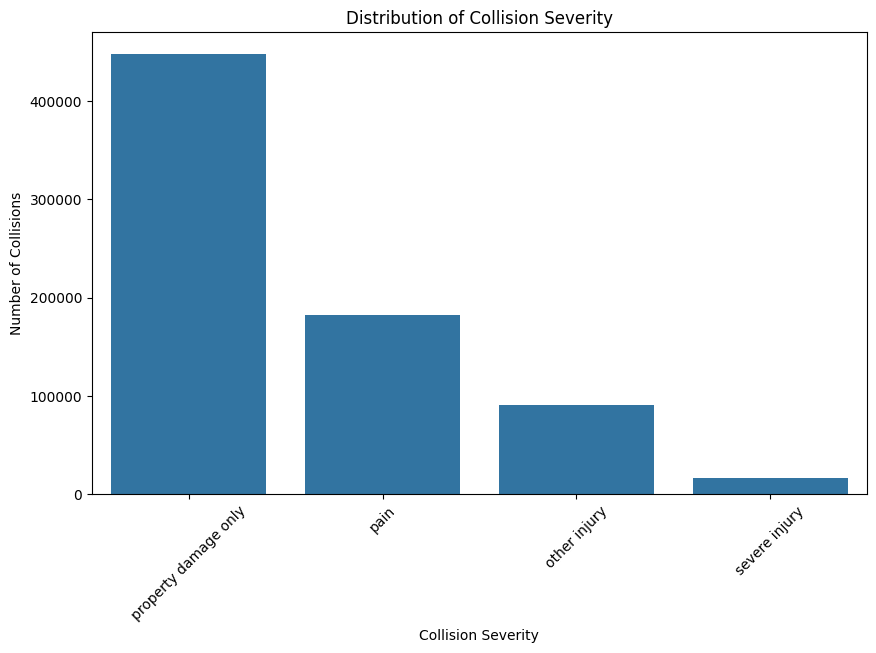

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the distribution of collision_severity in Spark
severity_counts = final_cleaned_df.groupBy("collision_severity").count().toPandas()

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='collision_severity', y='count', data=severity_counts)
plt.title('Distribution of Collision Severity')
plt.xlabel('Collision Severity')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45)
plt.show()

##**3.1.3. Weather conditions during collisions.** <font color = red>[5 marks]</font> <br>

Q: Examine weather conditions during collisions.

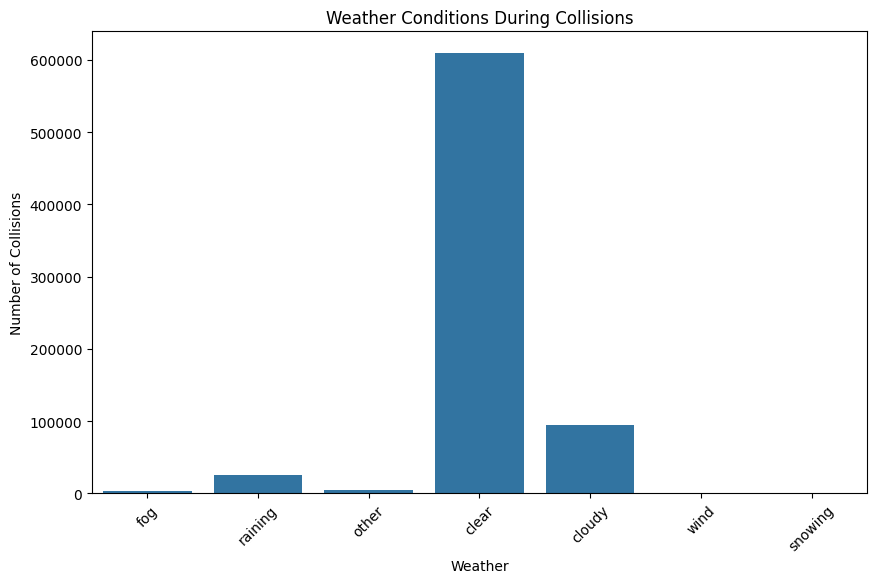

In [86]:
# Weather Conditions During Collisions
# Convert to Pandas
weather_collision_counts=final_cleaned_df.groupBy("weather").count().toPandas()

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="weather",y="count",data=weather_collision_counts)
plt.title("Weather Conditions During Collisions")
plt.xlabel("Weather")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.show()


##**3.1.4. Victime Age Distribution.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of victim ages.

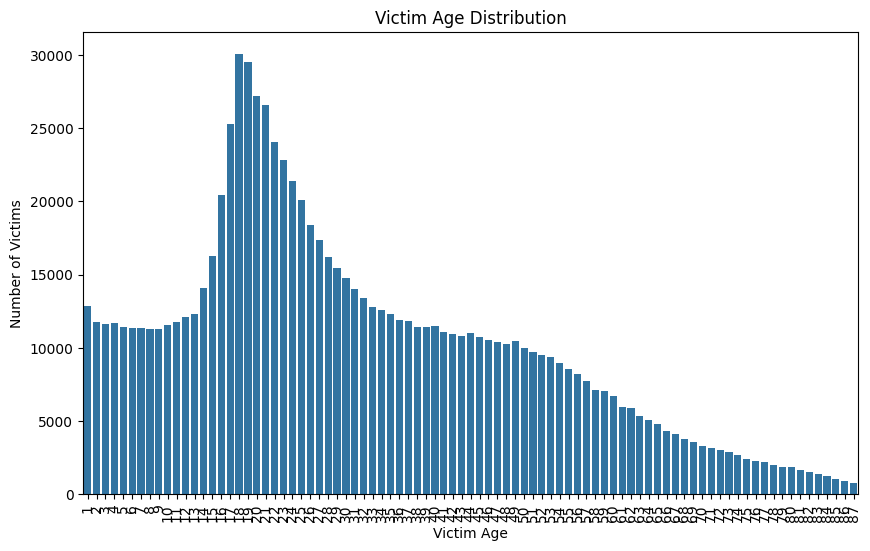

In [87]:
# Distribution of Victim Ages
# Convert to Pandas
victim_age_counts=final_cleaned_victim_df.groupBy("victim_age").count().toPandas()

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="victim_age",y="count",data=victim_age_counts)
plt.title("Victim Age Distribution")
plt.xlabel("Victim Age")
plt.ylabel("Number of Victims")
plt.xticks(rotation=90)
plt.show()


##**3.1.5. Collision Severity vs Number of Victims.** <font color = red>[5 marks]</font> <br>

Q: Study the relationship between collision severity and the number of victims.

In [88]:
# Bivariate Analysis

# Collision Severity vs. Number of Victims
# Convert to Pandas
severity_victim_counts=final_cleaned_df.join(final_cleaned_victim_df,on="case_id",how="inner").select(["collision_severity","id"]).groupBy("collision_severity").count().toPandas()


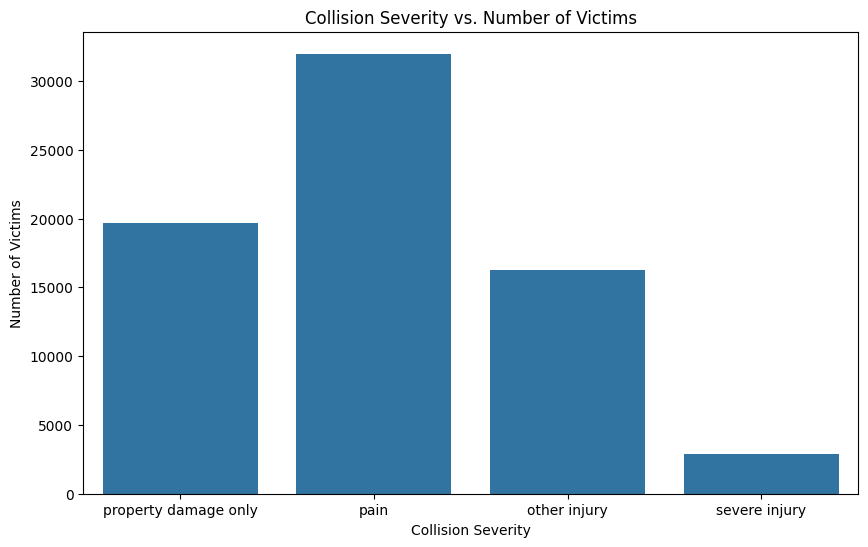

In [89]:
# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="collision_severity",y="count",data=severity_victim_counts)
plt.title("Collision Severity vs. Number of Victims")
plt.xlabel("Collision Severity")
plt.ylabel("Number of Victims")
plt.show()

##**3.1.6. Weather Conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the correlation between weather conditions and collision severity.

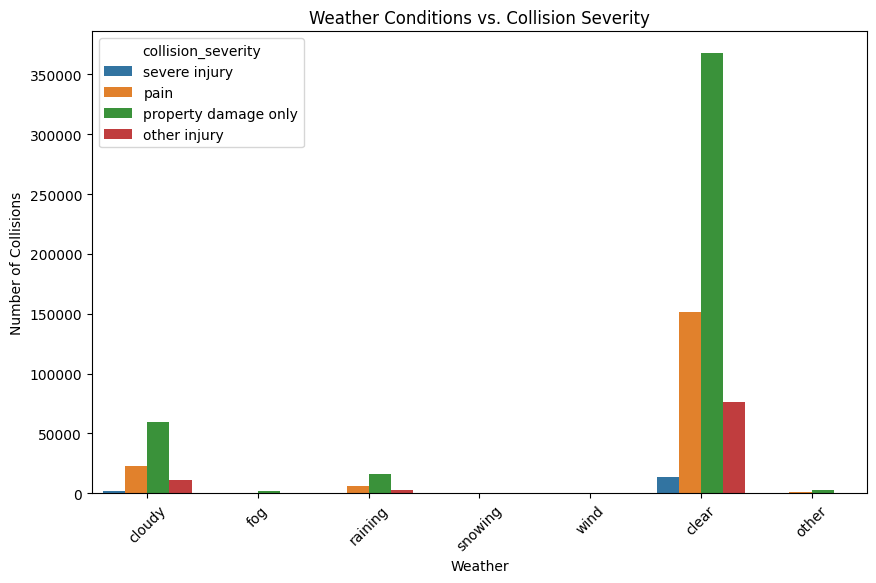

In [90]:
# Weather vs. Collision Severity
# Convert to Pandas
weather_collision_counts=final_cleaned_df.groupBy("weather","collision_severity").count().toPandas()

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="weather",y="count",hue="collision_severity",data=weather_collision_counts)
plt.title("Weather Conditions vs. Collision Severity")
plt.xlabel("Weather")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.show()


##**3.1.7. Lighting conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q:Visualize the impact of lighting conditions on collision severity.

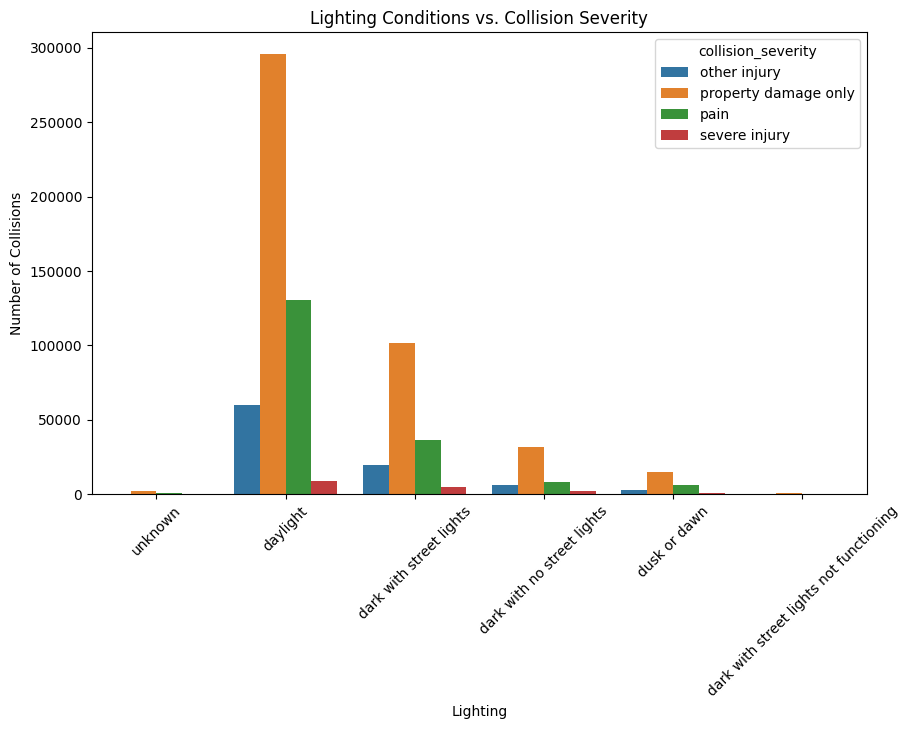

In [91]:
# Lighting Conditions vs. Collision Severity

# Convert to Pandas
lighting_collision_counts=final_cleaned_df.groupBy("lighting","collision_severity").count().toPandas()

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="lighting",y="count",hue="collision_severity",data=lighting_collision_counts)
plt.title("Lighting Conditions vs. Collision Severity")
plt.xlabel("Lighting")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.show()


##**3.1.8. Weekday-Wise Collision Trends.** <font color = red>[7 marks]</font> <br>

Q: Extract and analyze weekday-wise collision trends.

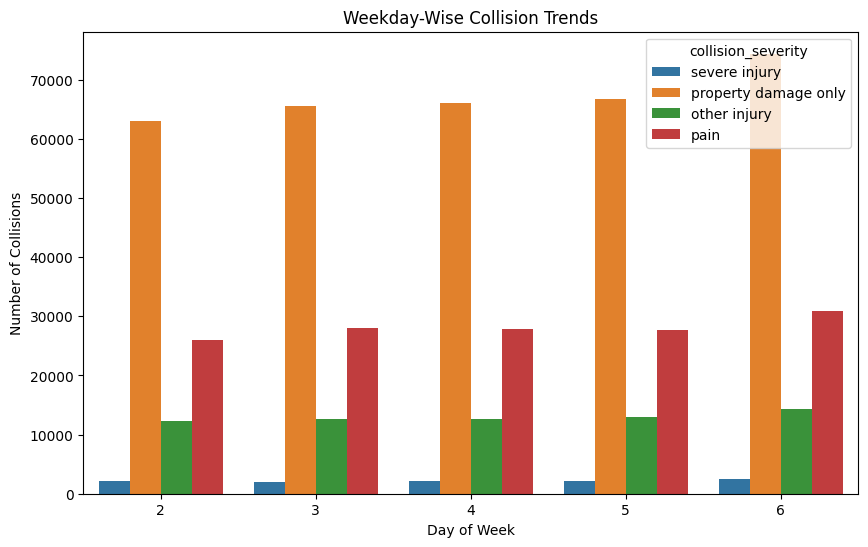

In [92]:
# Extract the weekday
final_cleaned_df=final_cleaned_df.withColumn("day_of_week",dayofweek(col("collision_date")))

collision_on_weekdays=final_cleaned_df.filter((col("day_of_week")>1) & (col("day_of_week")<7)).groupBy("day_of_week","collision_severity").count().toPandas()

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="day_of_week",y="count",hue="collision_severity",data=collision_on_weekdays)
plt.title("Weekday-Wise Collision Trends")
plt.xlabel("Day of Week")
plt.ylabel("Number of Collisions")
plt.show()


##**3.1.9. Spatial Distribution of Collisions.** <font color = red>[7 marks]</font> <br>

Q: Study spatial distribution of collisions by county.

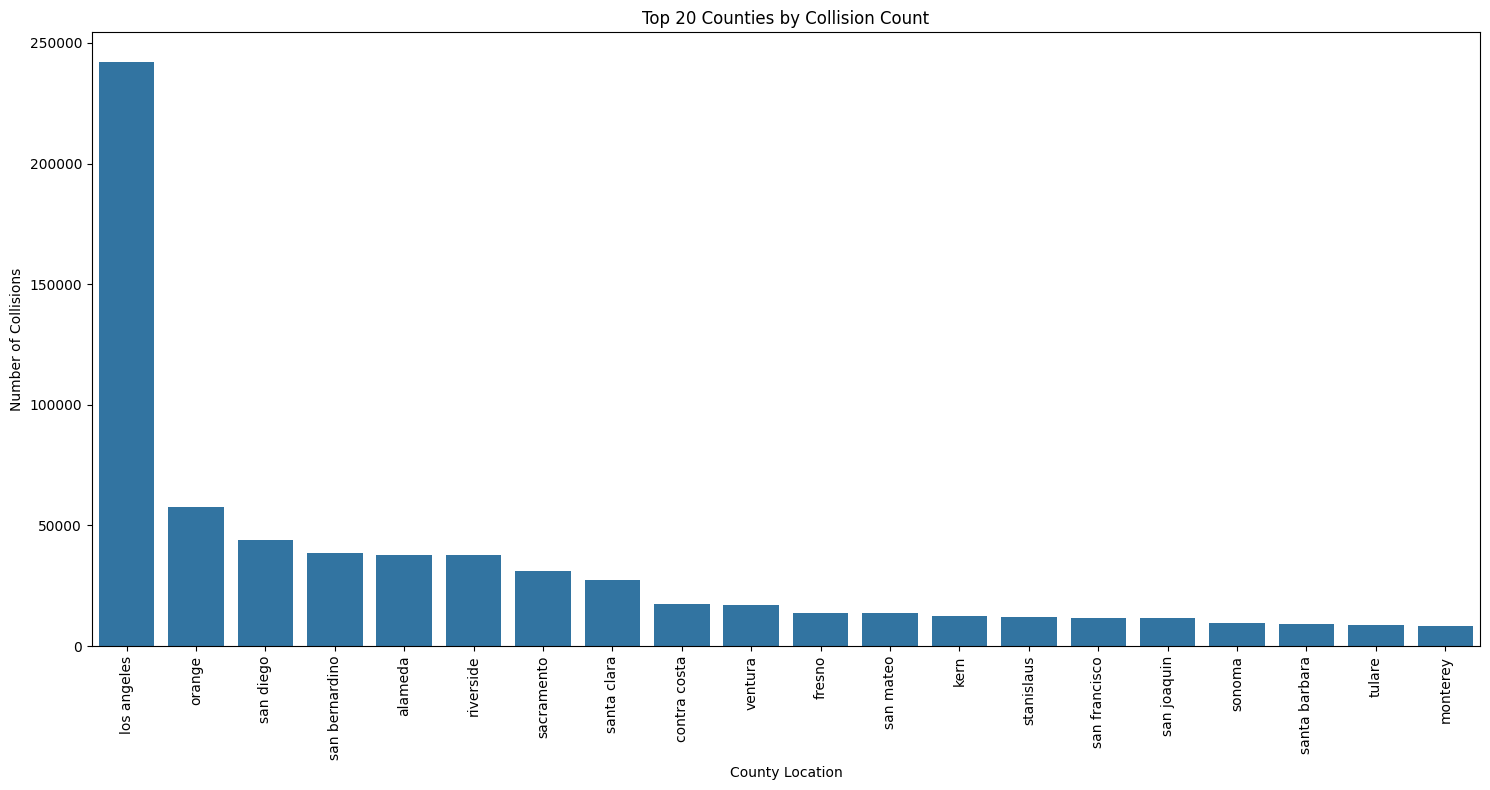

In [93]:
# Spatial Analysis

# Collision Density by County
county_collision_counts = final_cleaned_df.groupBy("county_location").count().orderBy(col("count").desc()).toPandas()

# Plot the map

plt.figure(figsize=(15, 8))
sns.barplot(x='county_location', y='count', data=county_collision_counts.head(20))
plt.title('Top 20 Counties by Collision Count')
plt.xlabel('County Location')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##**3.1.10. Collision Analysis by Geography.** <font color = red>[6 marks]</font> <br>

Q: Generate a scatter plot to analyze collision locations geographically.

In [ ]:
# Scatter Plot of Collision Locations

# Convert PySpark DataFrame to Pandas, handling potential missing values

# Convert to numeric (if needed) and handle invalid data

# Plot the scatter plot


##**3.1.11. Collision Trends Over Time.** <font color = red>[10 marks]</font> <br>

Extract and analyzing collision trends over time.

In [104]:
from os import name
from pyspark.sql.functions import year, month, hour, to_timestamp, date_format

# Extract year and month from collision_date
final_cleaned_df=final_cleaned_df.withColumn("year",year(col("collision_date")))
final_cleaned_df=final_cleaned_df.withColumn("month",date_format(col("collision_date"),"MMMM"))
final_cleaned_df=final_cleaned_df.withColumn("hour",hour(col("collision_time")))

# Plot
collision_trends_year_month=final_cleaned_df.groupBy("year","month").count().toPandas()




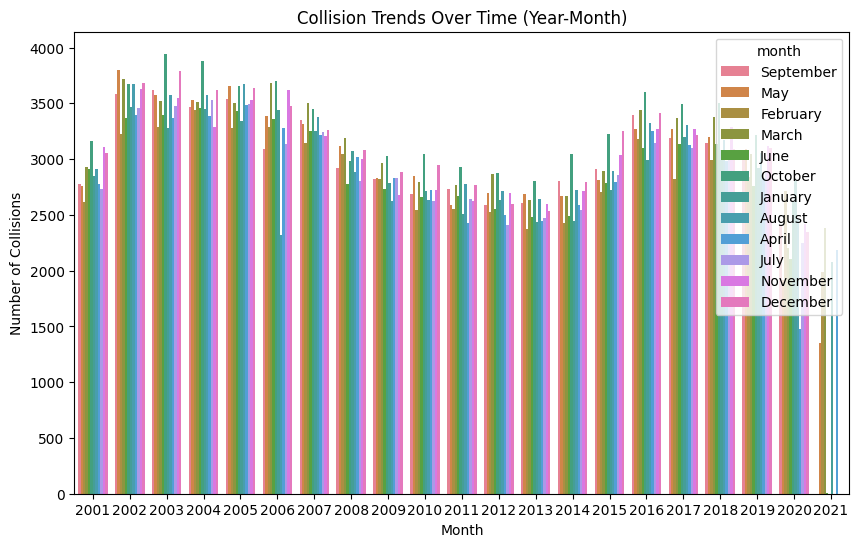

In [105]:
plt.figure(figsize=(10,6))
sns.barplot(x="year",y="count",hue="month",data=collision_trends_year_month)
plt.title("Collision Trends Over Time (Year-Month)")
plt.xlabel("Month")
plt.ylabel("Number of Collisions")
plt.show()

Q: Analyze yearly, monthly and hourly trends in collisions.

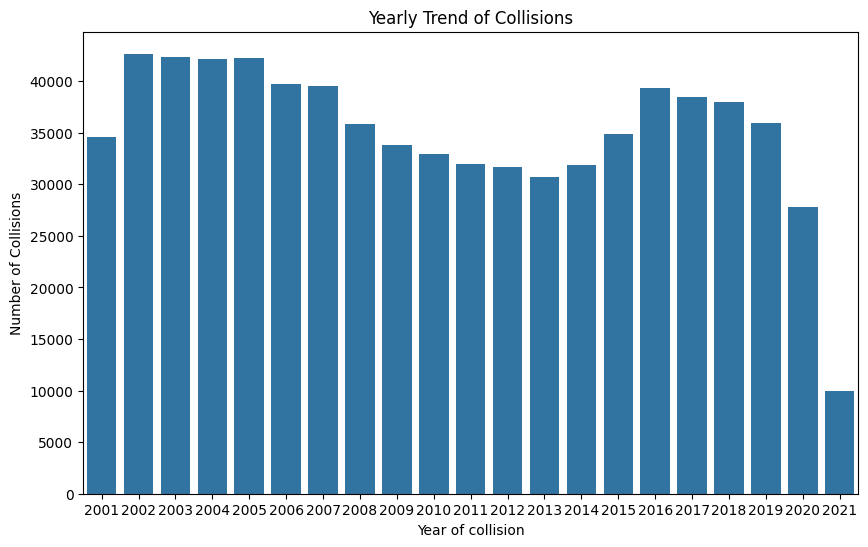

In [106]:
# Yearly Trend of Collisions
yearly_trends=final_cleaned_df.groupBy("year").count().toPandas()

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="year",y="count",data=yearly_trends)
plt.title("Yearly Trend of Collisions")
plt.xlabel("Year of collision")
plt.ylabel("Number of Collisions")
plt.show()



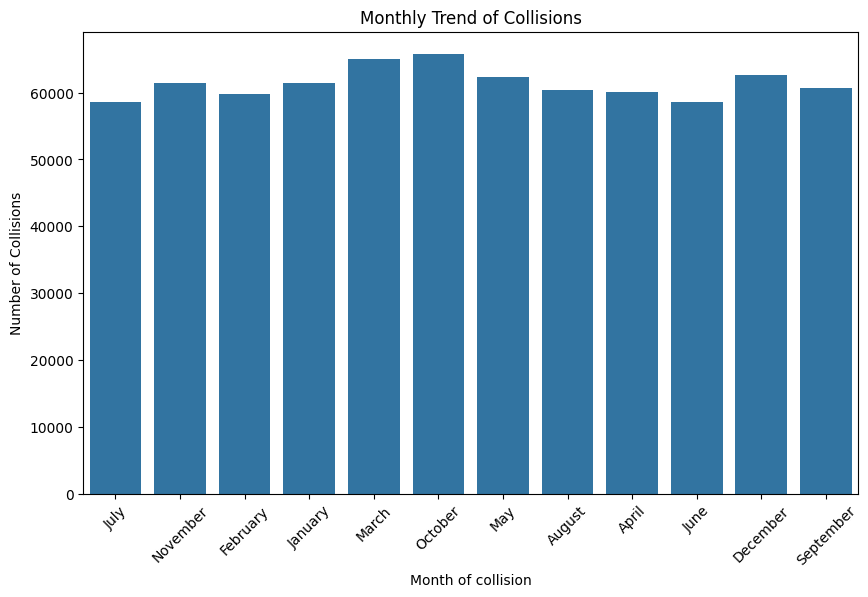

In [108]:
# Monthly Trend of Collisions
monhtly_trends=final_cleaned_df.groupBy("month").count().toPandas()

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="month",y="count",data=monhtly_trends)
plt.title("Monthly Trend of Collisions")
plt.xlabel("Month of collision")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.show()


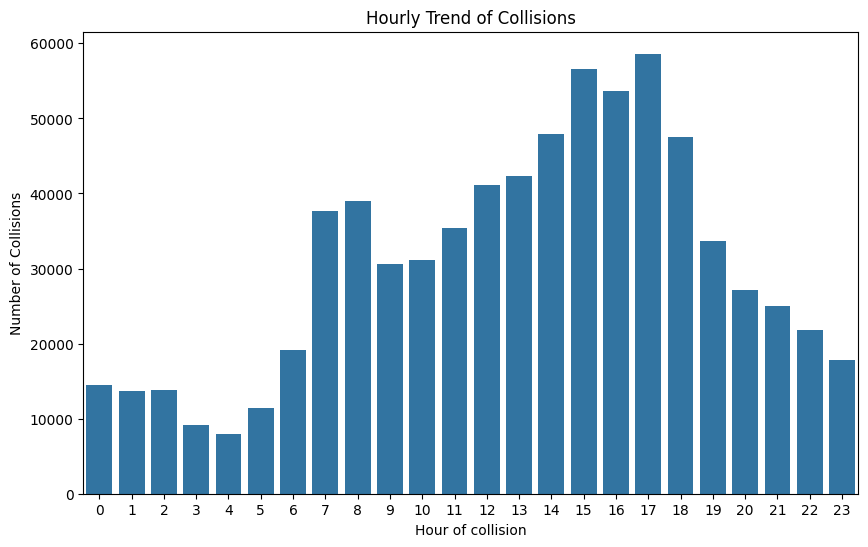

In [109]:
# Hourly Trend of Collisions
hourly_trends=final_cleaned_df.groupBy("hour").count().toPandas()

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="hour",y="count",data=hourly_trends)
plt.title("Hourly Trend of Collisions")
plt.xlabel("Hour of collision")
plt.ylabel("Number of Collisions")
plt.show()


#**4. ETL Querying** <font color = red>[35 marks]</font> <br>

## **4.1. Top 5 Counties** <font color = red>[4 marks]</font> <br>

Q: Identify the top 5 counties with the highest number of collisions.

In [100]:
# Query: Identify the top 5 counties with the most collisions
top_5_counties = final_cleaned_df.groupBy("county_location").count().orderBy(col("count").desc()).limit(5)
top_5_counties.show()

+---------------+------+
|county_location| count|
+---------------+------+
|    los angeles|242271|
|         orange| 57793|
|      san diego| 43916|
| san bernardino| 38390|
|        alameda| 37918|
+---------------+------+



## **4.2. Month with Highest Collisions** <font color = red>[5 marks]</font> <br>

Q. Identify the month with the highest number of collisions.

In [110]:
# Query: Find the month with the highest number of collisions
final_cleaned_df.groupBy("month").count().orderBy(col("count").desc()).limit(1).show()

+-------+-----+
|  month|count|
+-------+-----+
|October|65830|
+-------+-----+



## **4.3. Weather Conditions with Highest Collisions.** <font color = red>[5 marks]</font> <br>

Q. Determine the most common weather condition during collisions.

In [103]:
# Query: Find the most common weather condition during collisions
final_cleaned_df.groupBy("weather").count().orderBy(col("count").desc()).limit(1).show()

+-------+------+
|weather| count|
+-------+------+
|  clear|608893|
+-------+------+



## **4.4. Fatal Collisions.** <font color = red>[5 marks]</font> <br>

Q. Calculate the percentage of collisions that resulted in fatalities.

In [111]:
# Query: Determine the percentage of collisions that resulted in fatalities
final_cleaned_df.groupBy("collision_severity").count().show()


+--------------------+------+
|  collision_severity| count|
+--------------------+------+
|property damage only|447537|
|                pain|182418|
|        other injury| 90521|
|       severe injury| 16258|
+--------------------+------+



## **4.5. Dangerous Time for Collisions.** <font color = red>[5 marks]</font> <br>

Q. Find the most dangerous time of day for collisions.

In [112]:
# Query: Find the most dangerous time of day for collisions
final_cleaned_df.filter(col("collision_severity")=="severe injury").groupBy("hour").count().orderBy(col("count").desc()).limit(1).show()

+----+-----+
|hour|count|
+----+-----+
|  17| 1168|
+----+-----+



## **4.6. Road Surface Conditions.** <font color = red>[5 marks]</font> <br>

Q. Identify the top 5 road surface conditions with the highest collision frequency.

In [113]:
# Query: List the top 5 road types with the highest collision frequency
final_cleaned_df.groupby("road_condition").count().orderBy(col("count").desc()).limit(5).show()

+--------------+------+
|road_condition| count|
+--------------+------+
|        normal|710235|
|  construction| 10654|
|         other|  8751|
|   obstruction|  2508|
|         holes|  2113|
+--------------+------+



## **4.7. Lighting Conditions.** <font color = red>[5 marks]</font> <br>

Q. Analyze lighting conditions that contribute to the highest number of collisions.

In [114]:
# Query: Find the top 3 lighting conditions that lead to the most collisions
final_cleaned_df.groupBy("lighting").count().orderBy(col("count").desc()).limit(3).show()

+--------------------+------+
|            lighting| count|
+--------------------+------+
|            daylight|495265|
|dark with street ...|162788|
|dark with no stre...| 48017|
+--------------------+------+



#5. Conclusion <font color = red>[10 marks]</font> <br>

# Final insights and recommendations
## Insights:
Below are the observed insights for the traffic data set analysis.
1. The most collisions happens with less fatal injuries and its more of property damage.
2. Collisions are not very proportional to the conditions of weather. It is observed that the most of the collisions occured when weather is clear.
3. Most of the victims who were suffered from the collision are youngsters.
4. The lighting conditions are also not justification for the collision happened as it is observed the most of the collision occured on day light and in dark with proper lights.
5. The trend of collisions over weekends are very much similar with more cases of property damage.
6. Collision frequency is highly concentrated in urban counties. Spatial analysis reveled that densely populated counties experienced the highest collisions. Population density and traffic congestions are the strong contributors of collision occurance.
7. Coming to time series analysis in early 2000s the collisions were very high where the collisions experienced more in the month of October through out the decade.
8. When it comes to the trend over hour of the day, second half of the day being highest contributor to the totla collisions occured. especially at 1700 hour of the day it is highest. In the busier counties where population is dense return hour usually make the traffic more heavy which makes it more collision prone.
9. Even in the normal road conditions the collisions are very frequent.

## Recomendations:
1. From the above obseravtins it is clear that, the collision happening is not because of bad road condition nor lighting on the road, but because of the bad traffic management.
2. A better traffic management system has to be imposed especially in the big counties where the population is dense and traffic is more.
3. An error free traffic lights, better precautionary signs on intersecions can make the collision lower.
4. Deploy speed monitoring system so that speed obove a certain limit can be penalised and collisions can be brought down.
5. Allocate additional traffic resources especially during holiday months where collision risk are high.  


## Conclusions:
The California collision dataset analysis demonstrate that traffic collisions are influenced by a combination of
* driver behaviour
* Traffic density
* Environmental conditions
* geographical infrastructure differences




#6. Visualization Integration using Tableau/ PowerBI <font color = red>[Optional]</font> <br>